Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

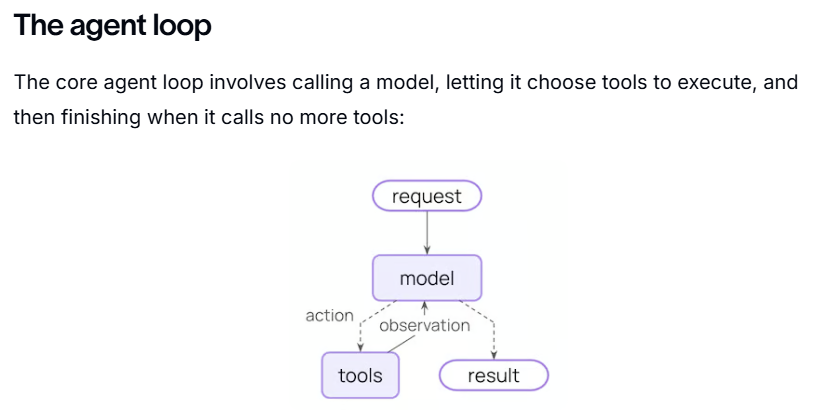

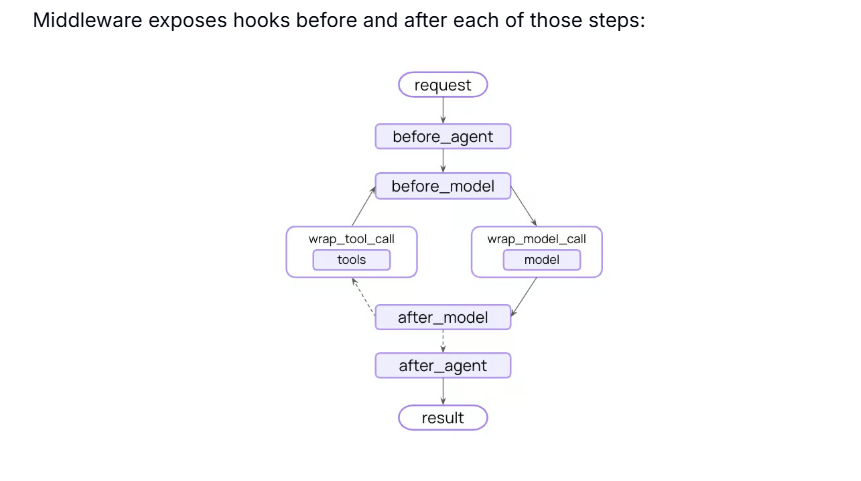

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

### Summarization MiddleWare

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

### Messagebased summarization
agent=create_agent(
    model="groq:qwen/qwen3-32b",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

In [3]:
### Run with thread id
config={"configurable":{"thread_id":"test-1"}}

In [4]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='e9e6701b-95e9-4617-a7bc-e8b1157798bc'), AIMessage(content='<think>\nOkay, the user is asking "What is 2+2?" That\'s a basic arithmetic question. Let me start by recalling that addition is one of the fundamental operations in mathematics. When you add two numbers, you combine their quantities. So, 2 plus 2 would be the sum of those two numbers.\n\nI know that in the decimal number system, which is the standard system we use, 2 represents the quantity of two. Adding two of them together would be like having two items and then adding another two items. So, 2 + 2 would equal 4. Let me verify that. If I count two apples and then another two apples, the total number of apples is four. That makes sense.\n\nWait, is there any context where 2+2 isn\'t 4? For example, in some modular arithmetic systems, like modulo 2, 2+2 would be 0. But the question doesn\'t specify any special context, 

https://docs.langchain.com/oss/python/langchain/middleware/built-in

### token Size

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [7]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~702 tokens, 6 messages
[HumanMessage(content="Here is a summary of the conversation to date:\n\n<think>\nOkay, let's see. The user wants me to extract the most important context from the provided conversation history. The main goal here is to replace the conversation history with a concise summary that captures the essential information.\n\nFirst, I need to identify the session intent. The user's primary goal is to find hotels in Paris. That's straightforward from the summary provided. The summary section lists three hotels with their details, which is crucial information. I need to make sure that each hotel's key features are included: names, star ratings, prices, and amenities. \n\nNext, artifacts. The hotel search results were generated using the `search_hotels` tool. There are no files mentioned, so it's just the data from the tool. \n\nFor next steps, the user needs to decide on a hotel, ask for booking help, or refine the search. I should list these options clearly. \n\nI

### Fraction

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:qwen/qwen3-32b",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~76 tokens (0.0594%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='bbd6c9b7-cab8-428c-9fd7-38253db5718f'), AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for hotels in Paris. Let me check the tools available. There's a function called search_hotels that requires a city parameter. Since the user specified Paris, I need to call that function with the city set to Paris. I'll make sure the arguments are correctly formatted as JSON within the tool_call tags.\n", 'tool_calls': [{'id': '0kd4yk1pz', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 147, 'total_tokens': 240, 'completion_time': 0.142055311, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0.007612047, 'prompt_tokens_details': None, 'queue_time': 0.056024793, 'total_time': 0.149667358}, 'mode

### Human In the Loop MiddleWare
Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [10]:
agent=create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)

In [11]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [12]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='90f4bbf8-1417-4efc-a14d-fe11849375f6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters are all strings. The user provided all three pieces of information: recipient is john@test.com, subject is Hello, body is How are you?. So I need to call send_email_tool with these arguments. No issues here, all required parameters are present. Just format the JSON correctly.\n", 'tool_calls': [{'id': 'r3t2kgpq7', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={

In [13]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email has been successfully sent to john@test.com with the subject "Hello". Let me know if you need further assistance!


In [14]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='90f4bbf8-1417-4efc-a14d-fe11849375f6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters are all strings. The user provided all three pieces of information: recipient is john@test.com, subject is Hello, body is How are you?. So I need to call send_email_tool with these arguments. No issues here, all required parameters are present. Just format the JSON correctly.\n", 'tool_calls': [{'id': 'r3t2kgpq7', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={

In [15]:
#Reject
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [16]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [17]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='ba1e8f58-8268-448c-8d87-f2d0b55a2394'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters are all strings. The user provided all three pieces of information: recipient is john@test.com, subject is Hello, body is How are you? So I need to call send_email_tool with those arguments. No issues here. Just make sure the JSON is correctly formatted with those values.\n", 'tool_calls': [{'id': '7zppjedtp', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'tok

In [18]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email to john@test.com with the subject "Hello" was not sent, as the tool call for `send_email_tool` was rejected. Would you like to try sending it again or adjust the message? Let me know how I can assist further.


In [19]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='ba1e8f58-8268-448c-8d87-f2d0b55a2394'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters are all strings. The user provided all three pieces of information: recipient is john@test.com, subject is Hello, body is How are you? So I need to call send_email_tool with those arguments. No issues here. Just make sure the JSON is correctly formatted with those values.\n", 'tool_calls': [{'id': '7zppjedtp', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'tok

In [20]:
#Editing
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [21]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [22]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='fc01e084-8e91-4118-b9f0-25aa2940e975'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let's see. The user wants to send an email to wrong@email.com with the subject 'Test' and body 'Hello'. I need to check which tool to use here. The available tools are read_email_tool and send_email_tool. Since the user is asking to send an email, the send_email_tool is the right choice.\n\nLooking at the parameters for send_email_tool, it requires recipient, subject, and body. The user provided all three: recipient is wrong@email.com, subject is 'Test', and body is 'Hello'. So I need to call the send_email_tool with these arguments. I should make sure the JSON structure is correct, using the parameter names as specified. No issues here, all required parameters are present. I'll format the tool_call accordingly.\n", 'tool_call

In [23]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: The email has been successfully sent to **correct@email.com** with the subject **"Corrected Subject"**. Let me know if you need further assistance!


In [24]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='fc01e084-8e91-4118-b9f0-25aa2940e975'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, let's see. The user wants to send an email to wrong@email.com with the subject 'Test' and body 'Hello'. I need to check which tool to use here. The available tools are read_email_tool and send_email_tool. Since the user is asking to send an email, the send_email_tool is the right choice.\n\nLooking at the parameters for send_email_tool, it requires recipient, subject, and body. The user provided all three: recipient is wrong@email.com, subject is 'Test', and body is 'Hello'. So I need to call the send_email_tool with these arguments. I should make sure the JSON structure is correct, using the parameter names as specified. No issues here, all required parameters are present. I'll format the tool_call accordingly.\n", 'tool_call